In [1]:
import pandas as pd
fake_df=pd.read_csv("Fake.csv")
true_df=pd.read_csv("True.csv")

In [2]:
true_df.tail()

,title,text,subject,date
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017"


In [3]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
fake_df['label']=0

In [5]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [6]:
true_df['label']=1

In [7]:
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [8]:
df=pd.concat([fake_df, true_df], ignore_index=True)

In [9]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [10]:
df.tail()

,title,text,subject,date,label
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
44897,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [11]:
df['content'] = df['title'] + ' ' + df['text']

In [12]:
df.head()

,title,text,subject,date,label,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,Pope Francis Just Called Out Donald Trump Dur...


In [13]:
df[['content', 'label']].isna().sum()

content    0
label      0
dtype: int64

In [14]:
df.shape

(44898, 6)

In [15]:
df=df[['content', 'label']].dropna()

In [16]:
df.shape

(44898, 2)

In [17]:
df.head()

,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,0


In [18]:
df.tail()

,content,label
44893,'Fully committed' NATO backs new U.S. approach...,1
44894,LexisNexis withdrew two products from Chinese ...,1
44895,Minsk cultural hub becomes haven from authorit...,1
44896,Vatican upbeat on possibility of Pope Francis ...,1
44897,Indonesia to buy $1.14 billion worth of Russia...,1


In [19]:
import re

def clean_text_simple(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+', '', text)   # remove URLs
    text = re.sub(r'<[^>]+>', '', text)        # remove HTML
    text = re.sub(r'[^a-z\s]', '', text)       # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()   # remove extra spaces
    
    # simple stopwords list
    stop_words = {
        'the','is','in','and','to','of','for','on','with','as','by','at','an','be','this','that'
    }
    
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    
    return " ".join(words)

In [20]:
df['cleaned'] = df['content'].apply(clean_text_simple)

In [21]:
df.head()

,content,label,cleaned
0,Donald Trump Sends Out Embarrassing New Year’...,0,donald trump sends out embarrassing new years ...
1,Drunk Bragging Trump Staffer Started Russian ...,0,drunk bragging trump staffer started russian c...
2,Sheriff David Clarke Becomes An Internet Joke...,0,sheriff david clarke becomes internet joke thr...
3,Trump Is So Obsessed He Even Has Obama’s Name...,0,trump obsessed even has obamas name coded into...
4,Pope Francis Just Called Out Donald Trump Dur...,0,pope francis just called out donald trump duri...


In [22]:
from sklearn.model_selection import train_test_split
X = df['cleaned']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
X_train

37645    socgen says wrongdoing handling national front...
30390    north carolina governor concedes election demo...
18191    trump fever dem senator says wont vote partydo...
25384    new york vows sue trump over immigrant childre...
32622    orlando killer expressed support multiple isla...
                               ...                        
9967     korea just revealed plans unleash unimaginable...
26591    trump meet top executives wireless tech drones...
8895     watch obama goes beast mode cnn anchor pushing...
18855    yikes hillary still needs help walking stagewa...
41192    chinas top paper warns party officials against...
Name: cleaned, Length: 35918, dtype: object

In [24]:
y_train

37645    1
30390    1
18191    0
25384    1
32622    1
        ..
9967     0
26591    1
8895     0
18855    0
41192    1
Name: label, Length: 35918, dtype: int64

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True   # applies log(TF) to dampen effect of very frequent words
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
}

In [27]:
results={}
for name,model in models.items():
    model.fit(X_train_vec,y_train)
    y_pred=model.predict(X_test_vec)
    results[name]=classification_report(y_test, y_pred, output_dict=True)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))


--- Naive Bayes ---
              precision    recall  f1-score   support

        Real       0.97      0.96      0.96      4696
        Fake       0.95      0.97      0.96      4284

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980


--- Logistic Regression ---
              precision    recall  f1-score   support

        Real       1.00      0.99      0.99      4696
        Fake       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



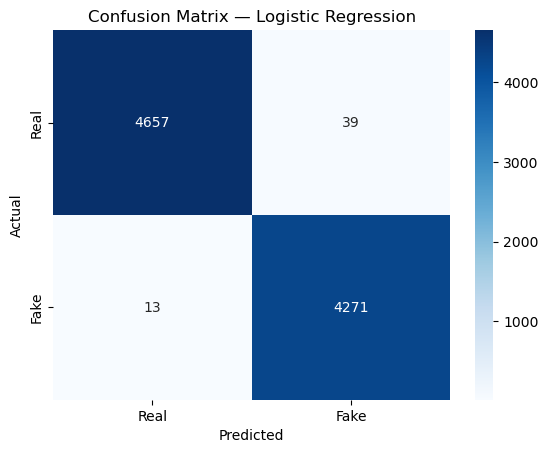

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
best_model = models['Logistic Regression']
y_pred_best = best_model.predict(X_test_vec)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [29]:
feature_names = vectorizer.get_feature_names_out()
coef = best_model.coef_[0]

In [30]:
top_fake_indices = coef.argsort()[-20:][::-1]
top_real_indices = coef.argsort()[:20]

In [31]:
print("\nTop words predicting FAKE news:")
for i in top_fake_indices:
    print(f"  {feature_names[i]:<25} weight: {coef[i]:.3f}")

print("\nTop words predicting REAL news:")
for i in top_real_indices:
    print(f"  {feature_names[i]:<25} weight: {coef[i]:.3f}")


Top words predicting FAKE news:
  reuters                   weight: 21.497
  said                      weight: 12.369
  washington reuters        weight: 8.856
  trumps                    weight: 6.444
  president donald          weight: 5.194
  wednesday                 weight: 4.412
  washington                weight: 4.343
  its                       weight: 4.064
  reuters president         weight: 3.995
  thursday                  weight: 3.898
  tuesday                   weight: 3.860
  republican                weight: 3.676
  friday                    weight: 3.498
  monday                    weight: 3.391
  dont                      weight: 3.386
  nov                       weight: 3.373
  told reuters              weight: 3.308
  minister                  weight: 3.290
  said statement            weight: 3.263
  thats                     weight: 2.966

Top words predicting REAL news:
  video                     weight: -9.455
  via                       weight: -7.694
  obam

In [32]:
def predict_article(text, model, vectorizer):
    cleaned = clean_text_simple(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0] if hasattr(model, 'predict_proba') else None
    label = "FAKE" if pred == 1 else "REAL"
    confidence = f"{max(prob)*100:.1f}%" if prob is not None else "N/A"
    print(f"Prediction: {label} (confidence: {confidence})")

In [33]:
predict_article("Scientists confirm new vaccine prevents disease effectively", best_model, vectorizer)
predict_article("Bill de Blasio is the new mayor of new york", best_model, vectorizer)

Prediction: REAL (confidence: 77.8%)
Prediction: REAL (confidence: 73.6%)


In [35]:
import pickle
import os

os.makedirs('model', exist_ok=True)

# Save the vectorizer (vocabulary + IDF scores)
with open('model/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Save the trained classifier
with open('model/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# If you used PCA/SVD, save that too
# with open('model/svd.pkl', 'wb') as f:
#     pickle.dump(svd, f)

print("Model saved successfully!")

Model saved successfully!
